# Ingredients List Dataset EDA

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

# Load ingredients list dataset
ingredients_df = pd.read_csv("../data/ingredientsList.csv")

print("Shape (rows, columns):", ingredients_df.shape)
print("\nColumn names:", ingredients_df.columns.tolist())
print("\nData types:")
print(ingredients_df.dtypes)
print("\nMissing values per column:")
print(ingredients_df.isna().sum())
print("\nFirst few rows:")
display(ingredients_df.head())

Shape (rows, columns): (248, 8)

Column names: ['name', 'scientific_name', 'short_description', 'what_is_it', 'what_does_it_do', 'who_is_it_good_for', 'who_should_avoid', 'url']

Data types:
name                  str
scientific_name       str
short_description     str
what_is_it            str
what_does_it_do       str
who_is_it_good_for    str
who_should_avoid      str
url                   str
dtype: object

Missing values per column:
name                    1
scientific_name       247
short_description       1
what_is_it              1
what_does_it_do         1
who_is_it_good_for      0
who_should_avoid        0
url                     0
dtype: int64

First few rows:


,name,scientific_name,short_description,what_is_it,what_does_it_do,who_is_it_good_for,who_should_avoid,url
0,Alpha-Glucan Oligosaccharide,NaN,Alpha-glucan oligosaccharide is in a class of ...,Prebiotics are a type of non-digestible dietar...,Prebiotics offer benefits such as:\r\n\r\n- He...,"[' ', 'Acne', ' ', 'Blackheads', ' ', 'Redness...","[' ', 'Related Allergy']",https://renude.co/ingredients/alpha-glucan-oli...
1,Aloe Vera,NaN,"Aloe vera, also appear on ingredients lists as...",Aloe vera is a skincare ingredient derived fro...,Aloe vera offers multiple benefits for the ski...,"[' ', 'Dry and dehydrated skin', ' ', 'Impaire...","[' ', 'Related Allergy']",https://renude.co/ingredients/aloe-vera
2,Allantoin,NaN,"Allantoin occurs naturally in the body, but ca...",Allantoin is a skincare ingredient derived fro...,"Allantoin is a calming, anti-inflammatory, and...","[' ', 'Fine Lines', ' ', 'Impaired skin barrie...","[' ', 'Related Allergy']",https://renude.co/ingredients/allantoin
3,Algin,NaN,"Algin, also known as sodium alginate, is a lar...",An extract from brown seaweed used as hydratin...,"In skincare products, it is used for its excel...","[' ', 'Dry and dehydrated skin', ' ', 'Fine Li...","[' ', 'Related Allergy']",https://renude.co/ingredients/algin
4,Algae Extract,NaN,"It is essentially an underwater plant, designe...",An incredibly interesting natural ingredient s...,Algae extracts are multifunctional ingredients...,"[' ', 'Dry and dehydrated skin', ' ', 'Fine Li...","[' ', 'Related Allergy']",https://renude.co/ingredients/algae-extract


In [2]:
# Text length analysis for each text column
text_cols = ["short_description", "what_is_it", "what_does_it_do"]

for col in text_cols:
    if col in ingredients_df.columns:
        ingredients_df[f"{col}_length"] = ingredients_df[col].astype(str).str.len()
        ingredients_df[f"{col}_word_count"] = ingredients_df[col].astype(str).str.split().str.len()

print("Text length statistics:")
print(ingredients_df[[f"{col}_length" for col in text_cols if col in ingredients_df.columns]].describe())

print("\nWord count statistics:")
print(ingredients_df[[f"{col}_word_count" for col in text_cols if col in ingredients_df.columns]].describe())

Text length statistics:
       short_description_length  what_is_it_length  what_does_it_do_length
count                247.000000         247.000000              247.000000
mean                 503.105263         191.623482              299.943320
std                  276.062274          69.674387              149.580215
min                   73.000000          31.000000               63.000000
25%                  280.500000         142.500000              144.500000
50%                  438.000000         196.000000              334.000000
75%                  695.500000         227.000000              426.500000
max                 1216.000000         420.000000              578.000000

Word count statistics:
       short_description_word_count  what_is_it_word_count  \
count                    247.000000             247.000000   
mean                      70.161943              28.692308   
std                       34.937664              10.164624   
min                       10.

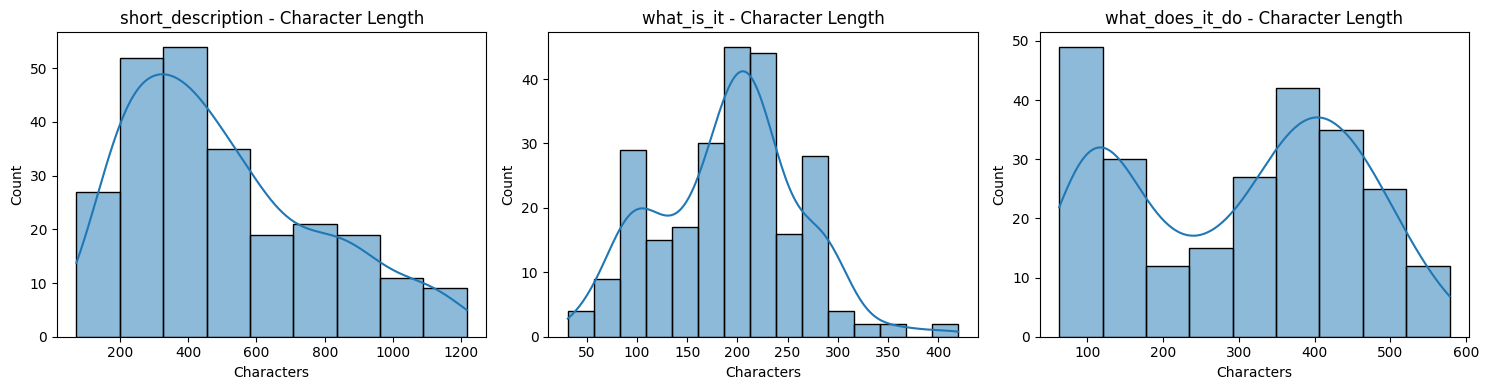

In [3]:
# Visualize text length distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, col in enumerate(text_cols):
    if col in ingredients_df.columns:
        sns.histplot(ingredients_df[f"{col}_length"], kde=True, ax=axes[idx])
        axes[idx].set_title(f"{col} - Character Length")
        axes[idx].set_xlabel("Characters")

plt.tight_layout()
plt.show()

Top 30 most common words (excluding stopwords):
skin: 1293
extract: 490
skincare: 255
acid: 252
used: 236
benefits: 234
ingredients: 222
palmitoyl: 222
properties: 203
anti: 200
which: 198
antioxidant: 195
natural: 182
helping: 152
found: 139
help: 127
free: 124
barrier: 121
offers: 119
against: 108
damage: 108
class: 107
protect: 105
algae: 105
derived: 103
inflammatory: 102
acids: 102
known: 102
improve: 100
amino: 100


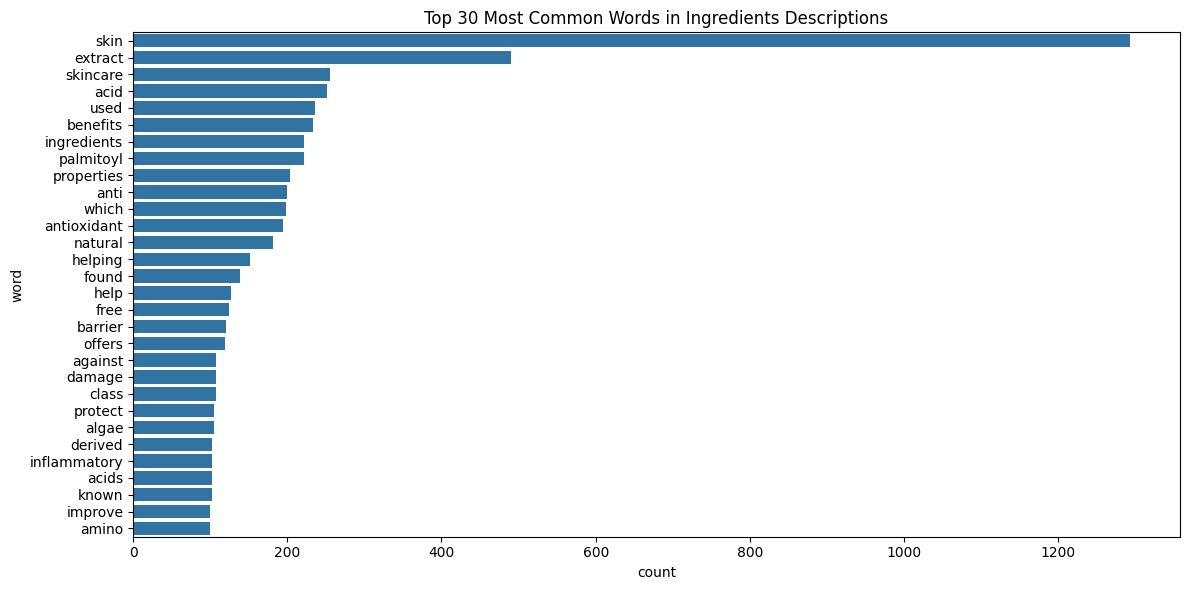

In [4]:
# Word frequency analysis - most common words across all text columns
def get_all_words(text_series):
    """Extract all words from a text series"""
    all_text = " ".join(text_series.astype(str).fillna(""))
    # Remove punctuation and convert to lowercase
    words = re.findall(r'\b[a-z]+\b', all_text.lower())
    return words

# Combine all text columns
all_text = " ".join(ingredients_df[text_cols].astype(str).fillna("").values.flatten())
words = re.findall(r'\b[a-z]+\b', all_text.lower())

# Remove common stopwords
stopwords = {'the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for', 'of', 'with', 'by', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'do', 'does', 'did', 'will', 'would', 'should', 'could', 'may', 'might', 'must', 'can', 'it', 'its', 'this', 'that', 'these', 'those', 'as', 'from', 'into', 'onto', 'up', 'down', 'out', 'off', 'over', 'under', 'again', 'further', 'then', 'once', 'also', 'such', 'than', 'more', 'most', 'very', 'just', 'now', 'well', 'so', 'too', 'when', 'where', 'why', 'how', 'all', 'each', 'every', 'both', 'few', 'many', 'other', 'some', 'no', 'not', 'only', 'own', 'same', 'so', 'than', 'too', 'very', 's', 't', 'can', 'will', 'just', 'don', 'should', 'now'}
words_filtered = [w for w in words if w not in stopwords and len(w) > 2]

word_freq = Counter(words_filtered)
top_words = word_freq.most_common(30)

print("Top 30 most common words (excluding stopwords):")
for word, count in top_words:
    print(f"{word}: {count}")

# Visualize
plt.figure(figsize=(12, 6))
words_df = pd.DataFrame(top_words, columns=["word", "count"])
sns.barplot(data=words_df, y="word", x="count")
plt.title("Top 30 Most Common Words in Ingredients Descriptions")
plt.tight_layout()
plt.show()

Sample of 'who_is_it_good_for' column:
0    [' ', 'Acne', ' ', 'Blackheads', ' ', 'Redness...
1    [' ', 'Dry and dehydrated skin', ' ', 'Impaire...
2    [' ', 'Fine Lines', ' ', 'Impaired skin barrie...
3    [' ', 'Dry and dehydrated skin', ' ', 'Fine Li...
4    [' ', 'Dry and dehydrated skin', ' ', 'Fine Li...
5    [' ', 'Dry and dehydrated skin', ' ', 'Fine Li...
6    [' ', 'Dry and dehydrated skin', ' ', 'Fine Li...
7    [' ', 'Dry and dehydrated skin', ' ', 'Pregnan...
8    [' ', 'Dry and dehydrated skin', ' ', 'Fine Li...
9    [' ', 'Acne', ' ', 'Dry and dehydrated skin', ...
Name: who_is_it_good_for, dtype: str

Top 20 conditions in 'who_is_it_good_for':
Pregnancy: 191
Dry and dehydrated skin: 97
Fine Lines: 93
Wrinkles: 78
Texture: 76
Redness: 66
Radiance: 66
Elasticity: 53
Impaired skin barrier: 45
Acne: 39
Blackheads: 37
Pigmentation: 31
Enlarged Pores: 24
Post Blemish Marks: 13
UV Protection: 9
Anyone: 5
Oily: 4
Dark Circles: 2
Eye Bags: 1


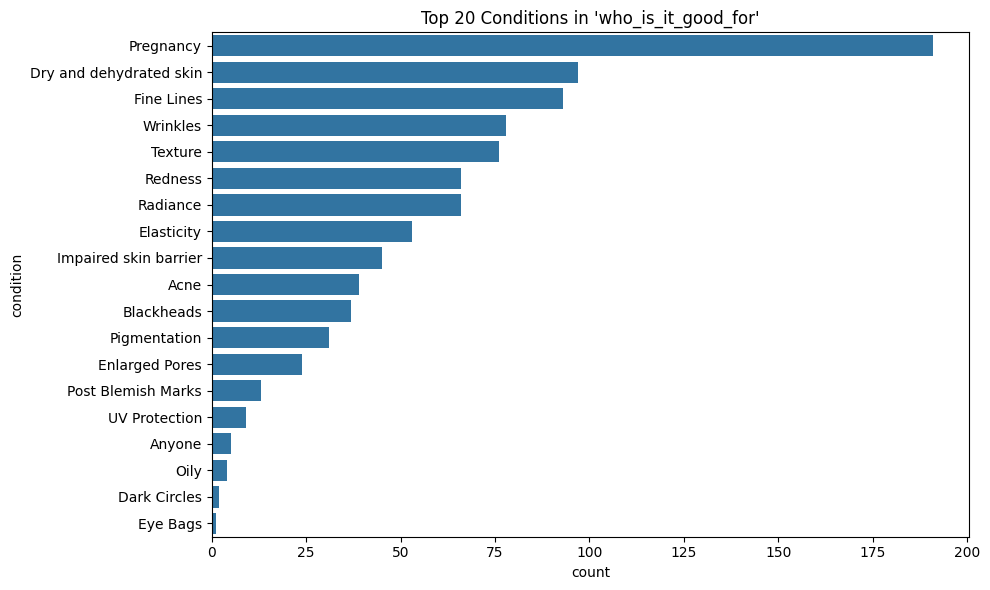

In [5]:
# Analyze "who_is_it_good_for" column - appears to have structured data
print("Sample of 'who_is_it_good_for' column:")
print(ingredients_df["who_is_it_good_for"].head(10))

# Extract conditions from the structured format
def extract_conditions(text):
    """Extract conditions from the list-like string format"""
    if pd.isna(text) or text == "":
        return []
    # Remove brackets and quotes, split by comma
    text = str(text).strip("[]'\"")
    conditions = [c.strip().strip("'\"") for c in text.split(",")]
    return [c for c in conditions if c and c != " "]

all_conditions = []
for text in ingredients_df["who_is_it_good_for"].dropna():
    conditions = extract_conditions(text)
    all_conditions.extend(conditions)

condition_freq = Counter(all_conditions)
top_conditions = condition_freq.most_common(20)

print("\nTop 20 conditions in 'who_is_it_good_for':")
for condition, count in top_conditions:
    print(f"{condition}: {count}")

plt.figure(figsize=(10, 6))
conditions_df = pd.DataFrame(top_conditions, columns=["condition", "count"])
sns.barplot(data=conditions_df, y="condition", x="count")
plt.title("Top 20 Conditions in 'who_is_it_good_for'")
plt.tight_layout()
plt.show()

Sample of 'who_should_avoid' column:
0    [' ', 'Related Allergy']
1    [' ', 'Related Allergy']
2    [' ', 'Related Allergy']
3    [' ', 'Related Allergy']
4    [' ', 'Related Allergy']
5    [' ', 'Related Allergy']
6    [' ', 'Related Allergy']
7    [' ', 'Related Allergy']
8    [' ', 'Related Allergy']
9    [' ', 'Related Allergy']
Name: who_should_avoid, dtype: str

Top 15 conditions in 'who_should_avoid':
Related Allergy: 230
Impaired skin barrier: 22
Sensitive: 21
Pregnancy: 18
Oily: 6
Dry Dehydrated: 5
Gluten Allery: 3
May leave a white cast on darker skin: 1
Combination: 1
Vegan: 1


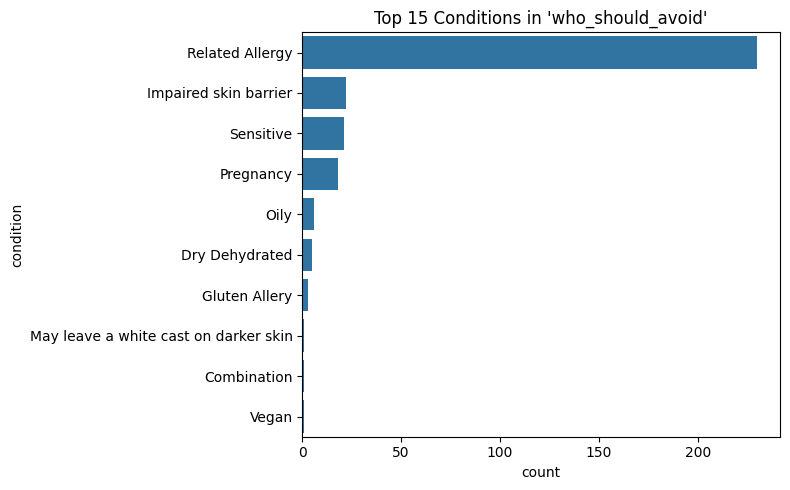

In [6]:
# Analyze "who_should_avoid" column
print("Sample of 'who_should_avoid' column:")
print(ingredients_df["who_should_avoid"].head(10))

all_avoid = []
for text in ingredients_df["who_should_avoid"].dropna():
    conditions = extract_conditions(text)
    all_avoid.extend(conditions)

avoid_freq = Counter(all_avoid)
top_avoid = avoid_freq.most_common(15)

print("\nTop 15 conditions in 'who_should_avoid':")
for condition, count in top_avoid:
    print(f"{condition}: {count}")

plt.figure(figsize=(8, 5))
avoid_df = pd.DataFrame(top_avoid, columns=["condition", "count"])
sns.barplot(data=avoid_df, y="condition", x="count")
plt.title("Top 15 Conditions in 'who_should_avoid'")
plt.tight_layout()
plt.show()

In [7]:
# Scientific name analysis
print("Number of ingredients with scientific names:", ingredients_df["scientific_name"].notna().sum())
print("Number of ingredients without scientific names:", ingredients_df["scientific_name"].isna().sum())

# Ingredients with longest descriptions
print("\nTop 10 ingredients by description length:")
top_by_desc = ingredients_df.nlargest(10, "what_does_it_do_length")[["name", "what_does_it_do_length"]]
print(top_by_desc)

# Ingredients with shortest descriptions
print("\nBottom 10 ingredients by description length:")
bottom_by_desc = ingredients_df.nsmallest(10, "what_does_it_do_length")[["name", "what_does_it_do_length"]]
print(bottom_by_desc)

Number of ingredients with scientific names: 1
Number of ingredients without scientific names: 247

Top 10 ingredients by description length:
                                               name  what_does_it_do_length
223                                 Tranexamic Acid                   578.0
205                                   Tartaric Acid                   571.0
210                            Superoxide Dismutase                   570.0
50   Bis-Ethylhexyloxyphenol Methoxyphenyl Triazine                   566.0
217                           Turmeric Root Extract                   550.0
190                           Snow Mushroom Extract                   539.0
61                              Chemical UV Filters                   538.0
239                                      Vitamin B5                   534.0
211                                   Sunflower Oil                   530.0
233                             Willow Bark Extract                   530.0

Bottom 10 ingredients

Frequency of key skincare terms in 'what_does_it_do':
            term  count
0    antioxidant     82
8        barrier     62
12    fine lines     48
11      wrinkles     47
5       soothing     38
6        calming     30
9       collagen     26
14  pigmentation     20
13          acne     19
19       vitamin     10
7         repair      9
15   brightening      8
1      hydrating      6
3     anti-aging      5
17       peptide      4
4    anti-ageing      4
21    hyaluronic      3
16   exfoliating      2
2   moisturizing      2
10       elastin      2
20      ceramide      1
18       retinol      0


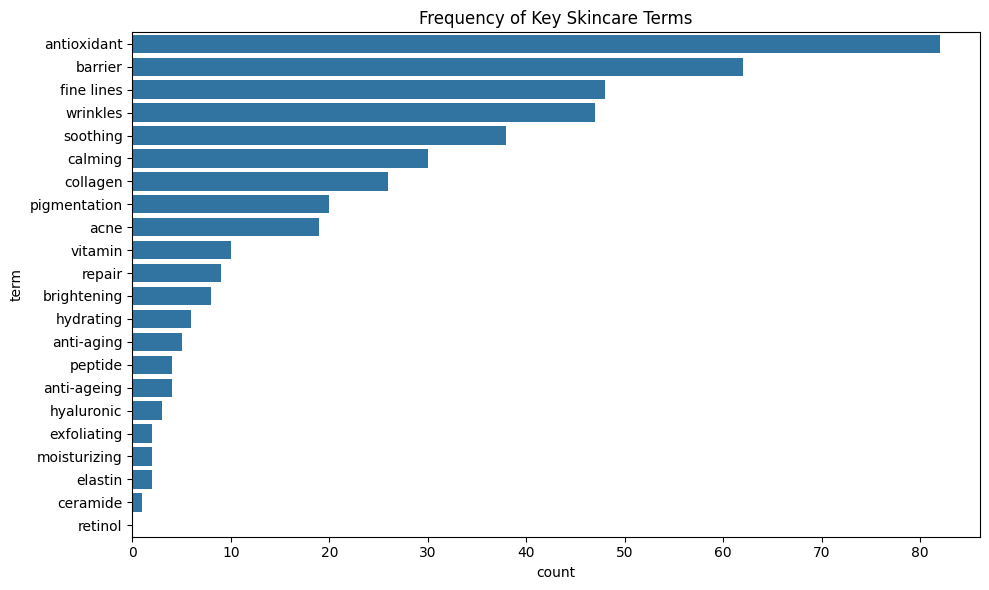

In [8]:
# Extract key skincare terms/buzzwords
skincare_terms = [
    "antioxidant", "hydrating", "moisturizing", "anti-aging", "anti-ageing", 
    "soothing", "calming", "repair", "barrier", "collagen", "elastin",
    "wrinkles", "fine lines", "acne", "pigmentation", "brightening",
    "exfoliating", "peptide", "retinol", "vitamin", "ceramide", "hyaluronic"
]

term_counts = {}
for term in skincare_terms:
    count = ingredients_df["what_does_it_do"].astype(str).str.lower().str.contains(term, na=False).sum()
    term_counts[term] = count

term_df = pd.DataFrame(list(term_counts.items()), columns=["term", "count"]).sort_values("count", ascending=False)

print("Frequency of key skincare terms in 'what_does_it_do':")
print(term_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=term_df, y="term", x="count")
plt.title("Frequency of Key Skincare Terms")
plt.tight_layout()
plt.show()

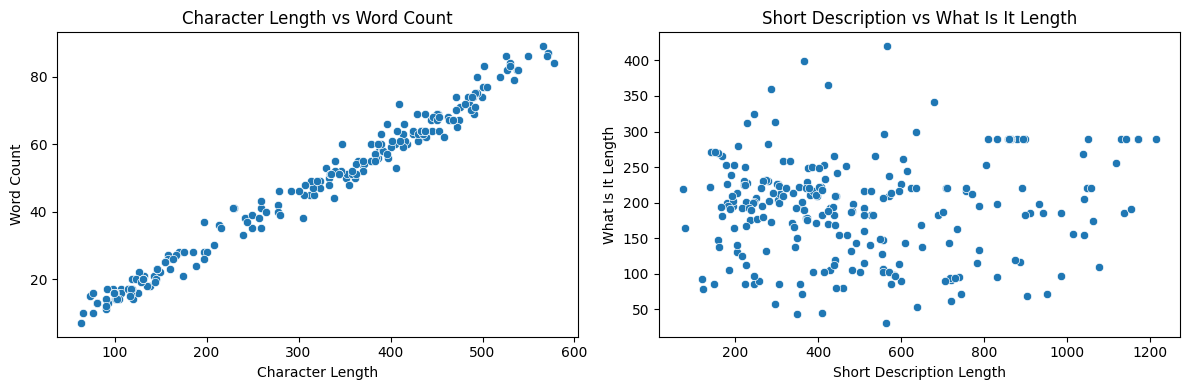

In [9]:
# Relationship between description length and word count
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.scatterplot(data=ingredients_df, x="what_does_it_do_length", y="what_does_it_do_word_count", ax=axes[0])
axes[0].set_title("Character Length vs Word Count")
axes[0].set_xlabel("Character Length")
axes[0].set_ylabel("Word Count")

sns.scatterplot(data=ingredients_df, x="short_description_length", y="what_is_it_length", ax=axes[1])
axes[1].set_title("Short Description vs What Is It Length")
axes[1].set_xlabel("Short Description Length")
axes[1].set_ylabel("What Is It Length")

plt.tight_layout()
plt.show()